# Feature Engineering 

**Project:** Airbnb Pricing Analysis

**Team:** Jessie Dicker, Norma Arredondo

**Date:** April 4, 2026




## Table of Contents
1. Load Preprocessed Data
2. Create New Features
3. Encode Categorical Features
4. Scale Numerical Features
5. Feature Selection
6. Save Final Data
7. Key Findings Summary

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

# 1. Load Preprocessed Data

This section loads the preprocessed train and test splits from Notebook 2 and confirms the data.

In [2]:
# load preprocessed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 39,107 rows x 10 columns
y_train Loaded: 39,107 rows x 1 columns
X_test Loaded: 9,777 rows x 10 columns
y_test Loaded: 9,777 rows x 1 columns


In [3]:
X_train.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Williamsburg,40.71151,-73.95937,Entire home/apt,1,1,1.00,2.0,1
1,Brooklyn,Williamsburg,40.71106,-73.94884,Entire home/apt,5,15,0.97,1.0,83
2,Manhattan,Inwood,40.86271,-73.92872,Entire home/apt,5,39,1.28,1.0,12
3,Brooklyn,Bushwick,40.70364,-73.92679,Private room,2,0,0.00,1.0,57
4,Brooklyn,Bedford-Stuyvesant,40.69360,-73.94653,Private room,1,1,0.02,1.0,0


In [4]:
# check column types

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (7): ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical (3): ['neighbourhood_group', 'neighbourhood', 'room_type']


### Load Preprocessed Data Observation

**Shapes of X_train and X_test**

X_train: (39107, 10)

X_test: (9777, 10)

**Number of Numerical and Categorical Features**

There are 7 Numerical Features: 

`latitude`, `longitude`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, and `availability_365`

There are 3 Categorical Features: 

`neighbourhood_group`, `neighbourhood`, and `room_type`

**The columns we planned to engineer new features from:**

- `latitude` & `longitude` — as a location-based feature
- `minimum_nights` — can be a log transformation
- `number_of_reviews` — can be binary flagged
- `number_of_reviews` & `availability_365` — can be combined into 
  a ratio feature


# 2. Create New Features

This section engineers new features using different techniques.

### 2.1 Log Transformation 

In [5]:
# Log transform minimum_nights to reduce right skew
X_train['log_minimum_nights'] = np.log1p(X_train['minimum_nights'])
X_test['log_minimum_nights'] = np.log1p(X_test['minimum_nights']) # identical as train

# no fitting needed
print("Original minimum_nights skew:", X_train['minimum_nights'].skew().round(2))
print("Log minimum_nights skew:     ", X_train['log_minimum_nights'].skew().round(2))

Original minimum_nights skew: 1.29
Log minimum_nights skew:      0.6


**Created Feature:**

Applied Log Transformation on `minimum_nights` to create `log_minimum_nights`. log(1 + x) was used to compute.


**Reason it was created:**

From our Exploratory Data Analysis, the `minimum_nights` is heavily right-skewed (skew = 1.29). The long tail can disrupt the model, so reducing the skew can help distribute it evenly. 


**Skewed Value:**

Original minimum_nights skew: 1.29
Log minimum_nights skew:      0.6

### 2.2 Location-based Feature

In [6]:
# Times Square: 40.7580° N, 73.9855° W
# Using longitude and latitude 

# Haversine distance to Times Square
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two lat/lon points."""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Distance to Times Square
X_train['dist_to_times_square'] = haversine_distance(
    X_train['latitude'], X_train['longitude'], 40.7580, -73.9855)
X_test['dist_to_times_square'] = haversine_distance(
    X_test['latitude'], X_test['longitude'], 40.7580, -73.9855)

# no fitting needed
print("Distance feature created!")
print(f"Avg distance to Times Square: {X_train['dist_to_times_square'].mean():.1f} km")

Distance feature created!
Avg distance to Times Square: 7.1 km


**Created Feature:**

`dist_to_times_square` was created using the Location-Based technique by calculating the kilometers using the Haversine distance formula with`longitude` and `latitude`.


**Reason it was created:**

In the Exploratory Data Analysis, `longitude` was the strongest predictor of price (r = -0.15). Geographically matters in this data, and Times Square is a popular landmark in New York City, which makes a good central landmark.  


**Average Distance:**

Average  distance to Times Square: 7.1 km

### 2.3 Binning 

In [7]:
# Binned Distance (dist_to_times_square)
bin_edges = [0, 2, 5, 10, 50]
bin_labels = ['Very Central', 'Central', 'Outer', 'Remote']

X_train['location_tier'] = pd.cut(
    X_train['dist_to_times_square'],
    bins=bin_edges,
    labels=bin_labels
)
X_test['location_tier'] = pd.cut(
    X_test['dist_to_times_square'],
    bins=bin_edges,
    labels=bin_labels
)

print("Training distribution:")
print(X_train['location_tier'].value_counts().sort_index())

Training distribution:
location_tier
Very Central     4466
Central          9152
Outer           17494
Remote           7995
Name: count, dtype: int64


**Created Feature:**

Binned the `dist_to_times_square` (the new feature) column into four distance zones using pd.cut(), to create `location_tier`.

- Very Central: 0-2 km
- Central: 2-5 km
- Outer: 5-10 km
- Remote: 10+ km


**Reason it was created:**

Instead of treating every kilometer as equal, binning captures the price impact of location. 1 km to Times Square isn't the same as 3km to Times Square.


**Training Distribution:**

- Very Central: 4,466 listings
- Central: 9,152 listings
- Outer: 17,494 listings
- Remote: 7,995 listings

### 2.4 Binary Flag

In [8]:
# Using number_of_reviews
# Flag listings with zero reviews
X_train['is_new_listing'] = (X_train['number_of_reviews'] == 0).astype(int)
X_test['is_new_listing'] = (X_test['number_of_reviews'] == 0).astype(int)

print("New listing flag distribution (train):")
print(X_train['is_new_listing'].value_counts())
print(f"\n{X_train['is_new_listing'].mean()*100:.1f}% of listings have no reviews")

New listing flag distribution (train):
is_new_listing
0    31086
1     8021
Name: count, dtype: int64

20.5% of listings have no reviews


**Created Feature:**

Created a binary column, `is_new_listing`, that flags listings where the listing has never received a review.

1 = listing has no reviews
0 = listing has at least one review


**Reason it was created:**

A Listing with zero reviews could mean a new listing, or it hasn't been booked yet. Listing with no reviews is a meaningful pricing signal that the raw `number_of_reviews` column could not be separated on its own. 

In the Data preprocessing notebook, we imputed missing values in `reviews_per_month` with no reviews. This flag is consistent with that earlier decision.


**Training Distribution:**

1 (no reviews): 31,086 listings

0 (at least one review): 8,021 listings

### 2.5 Ratio Feature

In [9]:
# Ratio using number_of_reviews and availability_365
X_train['review_density'] = (
    X_train['number_of_reviews'] / (X_train['availability_365'] + 1) # + 1 to avoid division by zero
)
X_test['review_density'] = (
    X_test['number_of_reviews'] / (X_test['availability_365'] + 1)  # + 1 to avoid division by zero
)

# Fit median on training data only
review_density_median = X_train['review_density'].median()

# Apply to both sets
X_train['review_density'] = X_train['review_density'].replace(
    [np.inf, -np.inf], review_density_median
)
X_test['review_density'] = X_test['review_density'].replace(
    [np.inf, -np.inf], review_density_median
)

print(f"Training median used for infinity replacement: {review_density_median:.4f}")
print()
print("Training distribution:")
print(X_train['review_density'].describe().round(3))

Training median used for infinity replacement: 0.2000

Training distribution:
count    39107.000
mean         3.319
std         12.897
min          0.000
25%          0.009
50%          0.200
75%          1.826
max        480.000
Name: review_density, dtype: float64


**Created Feature:**

Created `review_density` using the Ratio technique by dividing `number_of_reviews` by `availability_365`.


**Reason it was created:**

This new feature was created because using only `number_of_reviews` can be misleading. To determine the effectiveness of the number of reviews, density will rely on the availability of bookings and the number of reviews.


**Training Distribution:**
- Min: 0.000
- Median: 0.200
- Mean: 3.319
- Max: 480.0 (before capping)

In [10]:
# check outlier in new feature (review_density)
print(f"Outlier check:")
print(f"Values above 10: {(X_train['review_density'] > 10).sum()}")
print(f"Values above 50: {(X_train['review_density'] > 50).sum()}")

Outlier check:
Values above 10: 2754
Values above 50: 452


In [11]:
# Cap using training 99th percentile
cap_value = X_train['review_density'].quantile(0.99)
X_train['review_density'] = X_train['review_density'].clip(upper=cap_value)
X_test['review_density'] = X_test['review_density'].clip(upper=cap_value)

print(f"Capped at 99th percentile: {cap_value:.3f}")
print(f"New max: {X_train['review_density'].max():.3f}")

Capped at 99th percentile: 55.000
New max: 55.000


**Training Distribution:**
- Min: 0.000
- Median: 0.200
- Mean: 3.319
- New Max: 55.000 (before capping)

## Create New Features Observations


| Feature | Technique | Built From |
|---|---|---|
| `log_minimum_nights` | Log transformation | `minimum_nights` |
| `dist_times_square` | Location-based | `latitude` and `longitude` |
| `location_tier` | Binning | `dist_times_square` |
| `new_listing` | Binary flag | `number_of_reviews` |
| `review_density` | Ratio | `number_of_reviews` and `availability_365` |


# 3. Encode Categorical Features

This section converts the remaining categorical string columns to numeric. 

Ordinal Encoding: `location_tier` and `room_type`

One-Hot Encoding: `neighbourhood_group` and `neighbourhood`

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39107 entries, 0 to 39106
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             39107 non-null  object  
 1   neighbourhood                   39107 non-null  object  
 2   latitude                        39107 non-null  float64 
 3   longitude                       39107 non-null  float64 
 4   room_type                       39107 non-null  object  
 5   minimum_nights                  39107 non-null  int64   
 6   number_of_reviews               39107 non-null  int64   
 7   reviews_per_month               39107 non-null  float64 
 8   calculated_host_listings_count  39107 non-null  float64 
 9   availability_365                39107 non-null  int64   
 10  log_minimum_nights              39107 non-null  float64 
 11  dist_to_times_square            39107 non-null  float64 
 12  location_tier     

### 3.1 Ordinal Encoding

In [13]:
# Ordinal Encoding on location_tier
from sklearn.preprocessing import OrdinalEncoder

location_tier_order = [['Very Central', 'Central', 'Outer', 'Remote']]

location_tier_encoder = OrdinalEncoder(categories=location_tier_order, 
                             handle_unknown='use_encoded_value', 
                             unknown_value=-1)

# Convert to string first to handle Categorical dtype from pd.cut
X_train['location_tier'] = X_train['location_tier'].astype(str)
X_test['location_tier'] = X_test['location_tier'].astype(str)

X_train['location_tier_encoded'] = location_tier_encoder.fit_transform(
    X_train[['location_tier']]
)
X_test['location_tier_encoded'] = location_tier_encoder.transform(
    X_test[['location_tier']]
)

# print the mapping
print('location_tier mapping:')
for i, level in enumerate(location_tier_encoder.categories_[0]):
    print(f'{level} = {i}')

location_tier mapping:
Very Central = 0
Central = 1
Outer = 2
Remote = 3


In [14]:
# Ordinal Encoding on room_type
room_type_order = [['Shared room', 'Private room', 'Entire home/apt']]

room_type_encoder = OrdinalEncoder(categories=room_type_order, 
                             handle_unknown='use_encoded_value', 
                             unknown_value=-1)

X_train['room_type_encoded'] = room_type_encoder.fit_transform(
    X_train[['room_type']]
)
X_test['room_type_encoded'] = room_type_encoder.transform(
    X_test[['room_type']]
)

# print the mapping
print("room_type mapping:")
for i, category in enumerate(room_type_encoder.categories_[0]):
    print(f"  {category} = {i}")

room_type mapping:
  Shared room = 0
  Private room = 1
  Entire home/apt = 2


In [15]:
# drop original categorical columns
X_train = X_train.drop(columns=['location_tier', 'room_type'])
X_test = X_test.drop(columns=['location_tier', 'room_type'])
print("Original ordinal columns dropped")

Original ordinal columns dropped


### 3.3 One-Hot Encoding

In [16]:
# One-Hot Encoding — neighbourhood_group
ng_dummies_train = pd.get_dummies(X_train['neighbourhood_group'], prefix='neighbourhood_group', drop_first=True, dtype=int)
X_train = pd.concat([X_train, ng_dummies_train], axis=1)
X_train = X_train.drop('neighbourhood_group', axis=1)

ng_dummies_test = pd.get_dummies(X_test['neighbourhood_group'], prefix='neighbourhood_group', drop_first=True, dtype=int)
X_test = pd.concat([X_test, ng_dummies_test], axis=1)
X_test = X_test.drop('neighbourhood_group', axis=1)

print("neighbourhood_group encoded")

neighbourhood_group encoded


In [17]:
# One-Hot Encoding — neighbourhood
nb_dummies_train = pd.get_dummies(X_train['neighbourhood'], prefix='neighbourhood', drop_first=True, dtype=int)
X_train = pd.concat([X_train, nb_dummies_train], axis=1)
X_train = X_train.drop('neighbourhood', axis=1)

nb_dummies_test = pd.get_dummies(X_test['neighbourhood'], prefix='neighbourhood', drop_first=True, dtype=int)
X_test = pd.concat([X_test, nb_dummies_test], axis=1)
X_test = X_test.drop('neighbourhood', axis=1)

print("neighbourhood encoded")

neighbourhood encoded


In [18]:
# align columns 
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"\nX_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding:  {X_test.shape}")


X_train shape after encoding: (39107, 235)
X_test shape after encoding:  (9777, 235)


In [19]:
# check for any remaining objects
remaining_objects_train = X_train.select_dtypes(include='object').columns.tolist()
remaining_objects_test = X_test.select_dtypes(include='object').columns.tolist()

print(f"Remaining string columns in X_train: {remaining_objects_train}")
print(f"Remaining string columns in X_test:  {remaining_objects_test}")

if not remaining_objects_train and not remaining_objects_test:
    print(" All categorical columns encoded")

# print final shapes
print(f"\nFinal shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

Remaining string columns in X_train: []
Remaining string columns in X_test:  []
 All categorical columns encoded

Final shapes:
  X_train: (39107, 235)
  X_test:  (9777, 235)


## Encode Categorical Features Observations

**Encoding Methods Used:**

| Column | Encoding Method | Reason |
|---|---|---|
| `location_tier` | Ordinal Encoding | Natural order exists: Very Central -> Central -> Outer -> Remote |
| `room_type` | Ordinal Encoding | Natural order in privacy and price: Shared room < Private room < Entire house/appartment |
| `neighbourhood_group` | One-Hot Encoding | 5 unordered between borough categories |
| `neighbourhood` | One-Hot Encoding | Unordered neighbourhood categories |



**Total Column Count After Encoding:**

X_train: 235 Columns

X_test:  235 Columns


The `neighbourhood` column has a lot of unique values, which is why there's a significant increase in column count.

# 4. Scale Numerical Features 

This section will scale numerical features in the training data ONLY, to be used in modeling. 

In [20]:
# First, we will check the feature ranges in the training data:
print("Feature ranges BEFORE scaling:")
print(X_train.describe().loc[['min', 'max']].round(2))

Feature ranges BEFORE scaling:
     latitude  longitude  minimum_nights  number_of_reviews  \
min     40.50     -74.24             1.0                0.0   
max     40.91     -73.71            11.0              629.0   

     reviews_per_month  calculated_host_listings_count  availability_365  \
min                0.0                             1.0               0.0   
max               58.5                             3.5             365.0   

     log_minimum_nights  dist_to_times_square  is_new_listing  review_density  \
min                0.69                  0.07             0.0             0.0   
max                2.48                 35.90             1.0            55.0   

     location_tier_encoded  room_type_encoded  neighbourhood_group_Brooklyn  \
min                    0.0                0.0                           0.0   
max                    3.0                2.0                           1.0   

     neighbourhood_group_Manhattan  neighbourhood_group_Queens  \
mi

In [22]:
# Based on the results above, the folowing columns need to be scaled:
cols_to_scale = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'dist_to_times_square',
    'review_density',
    'log_minimum_nights',
    'calculated_host_listings_count',
    'location_tier_encoded'
]

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train[cols_to_scale])
X_test_standard = scaler.transform(X_test[cols_to_scale])

X_train_standard = pd.DataFrame(X_train_standard, columns=cols_to_scale, index=X_train.index)
X_test_standard = pd.DataFrame(X_test_standard, columns=cols_to_scale, index=X_test.index)

print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train_standard.mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_train_standard.std().round(4).head())

Scaling complete

 Sample mean (should be ~0 for train):
latitude            -0.0
longitude            0.0
minimum_nights       0.0
number_of_reviews   -0.0
reviews_per_month    0.0
dtype: float64

 Sample stds (should be ~1 for train):
latitude             1.0020
longitude            0.9969
minimum_nights       1.0076
number_of_reviews    0.9567
reviews_per_month    0.9477
dtype: float64


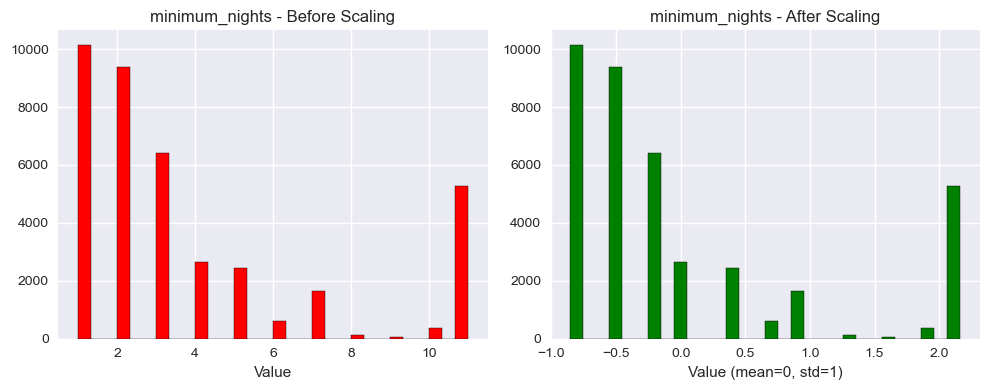

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

feature = 'minimum_nights'

axes[0].hist(X_train[feature], bins=30, color='red', edgecolor='black')
axes[0].set_title(f'{feature} - Before Scaling')
axes[0].set_xlabel('Value')

axes[1].hist(X_train_standard[feature], bins=30, color='green', edgecolor='black')
axes[1].set_title(f'{feature} - After Scaling')
axes[1].set_xlabel('Value (mean=0, std=1)')

plt.tight_layout()
plt.show()

## Scaling Features Takeaways:

**Scaled Features:**
The following features were scaled because they werre continuous or ordinal numeric variables:
* `latitude`
* `longitude`
* `minimum_nights`
* `number_of_reviews`
* `reviews_per_month`
* `availability_365`
* `dist_to_times_square`
* `review_density`
* `log_minimum_nights`
* `calculated_host_listings_count`
* `location_tier_encoded`

**Features that were NOT scaled:**

| Feauture | Reason |
|---|---|
| `is_new_listing` | This is a binary variable | 
| `room_type_encoded` | Nominal categorical variable with no inherent order | 
| All `neighbourhood_` variables | One-hot encoded variable |
| All `neighbourhood_group_` variables | One-hot encoded variable |

**Scaling Verification:**
The following results were obtained above, where the mean of scaled variables were checked to make sure they are around zero:

- latitude            -0.0
- longitude            0.0
- minimum_nights       0.0
- number_of_reviews   -0.0
- reviews_per_month    0.0

And the standard deviations are around 1:
- latitude             1.0020
- longitude            0.9969
- minimum_nights       1.0076
- number_of_reviews    0.9567
- reviews_per_month    0.9477


# 5. Feature Selection

In [41]:
correlation_matrix = pd.concat([X_train_standard,y_train],axis=1).corr()
correlation_matrix

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,availability_365,dist_to_times_square,review_density,log_minimum_nights,calculated_host_listings_count,location_tier_encoded,price
latitude,1.000000,0.084117,0.027975,-0.014611,-0.017005,-0.010351,-0.410495,0.004080,0.018738,-0.001648,-0.333336,0.037174
longitude,0.084117,1.000000,-0.122382,0.065030,0.142914,0.083022,0.538710,-0.023221,-0.132789,0.083321,0.475550,-0.158417
minimum_nights,0.027975,-0.122382,1.000000,-0.178747,-0.279724,0.152696,-0.144025,-0.098070,0.966731,0.184362,-0.133495,0.029584
number_of_reviews,-0.014611,0.065030,-0.178747,1.000000,0.588355,0.173952,0.061882,0.188274,-0.176784,0.050124,0.052303,-0.050332
reviews_per_month,-0.017005,0.142914,-0.279724,0.588355,1.000000,0.165861,0.117209,0.095327,-0.295114,0.091370,0.082058,-0.051912
availability_365,-0.010351,0.083022,0.152696,0.173952,0.165861,1.000000,0.087015,-0.288481,0.108563,0.413992,0.027683,0.086999
dist_to_times_square,-0.410495,0.538710,-0.144025,0.061882,0.117209,0.087015,1.000000,-0.025299,-0.143324,0.043616,0.873188,-0.181746
review_density,0.004080,-0.023221,-0.098070,0.188274,0.095327,-0.288481,-0.025299,1.000000,-0.085344,-0.084266,-0.006469,-0.044961
log_minimum_nights,0.018738,-0.132789,0.966731,-0.176784,-0.295114,0.108563,-0.143324,-0.085344,1.000000,0.119283,-0.124770,0.031831
calculated_host_listings_count,-0.001648,0.083321,0.184362,0.050124,0.091370,0.413992,0.043616,-0.084266,0.119283,1.000000,0.004910,-0.014331


In [42]:
print("Correlations with Price:")
correlations = correlation_matrix['price'].abs().sort_values(ascending=False)
correlations = correlations.drop('price')
correlations

Correlations with Price:


location_tier_encoded             0.202908
dist_to_times_square              0.181746
longitude                         0.158417
availability_365                  0.086999
reviews_per_month                 0.051912
number_of_reviews                 0.050332
review_density                    0.044961
latitude                          0.037174
log_minimum_nights                0.031831
minimum_nights                    0.029584
calculated_host_listings_count    0.014331
Name: price, dtype: float64

In [44]:
print('Top 5 features correlated with target:')
print(correlations.head(5).round(4))
print(f'\nBottom 5:')
print(correlations.tail(5).round(4))

Top 5 features correlated with target:
location_tier_encoded    0.2029
dist_to_times_square     0.1817
longitude                0.1584
availability_365         0.0870
reviews_per_month        0.0519
Name: price, dtype: float64

Bottom 5:
review_density                    0.0450
latitude                          0.0372
log_minimum_nights                0.0318
minimum_nights                    0.0296
calculated_host_listings_count    0.0143
Name: price, dtype: float64


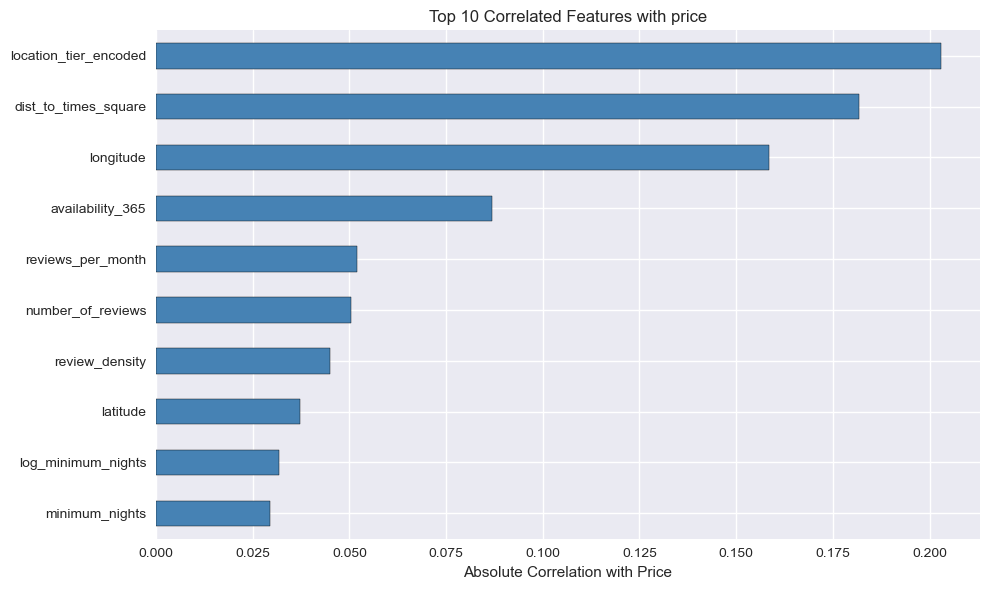

In [45]:
top10 = correlations.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='steelblue',edgecolor='black')
plt.xlabel('Absolute Correlation with Price')
plt.title('Top 10 Correlated Features with price')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [46]:
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [47]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df

Highly correlated feature pairs (>0.8):


,Feature 1,Feature 2,Correlation
0,minimum_nights,log_minimum_nights,0.966731
1,dist_to_times_square,location_tier_encoded,0.873188


## Feature Selection Takeaways:

**Top Features Correlated with Price:**

The three features with the highest correlation with the target variable `price` are:

- `location_tier_encoded` **0.2029**  
- `dist_to_times_square` **0.1817**
- `longitude` **0.1584**

The results of this analysis show that location information is most correlated with AirBnB price, which makes sense as these are typical indicators of this variable. The proximity to tourist attractions such as Times Square would drive price up for vacation rentals, for instance. 


**Engineered vs. Original Features:**

- `dist_to_times_square` **(0.1817)** outperformed raw `longitude` **(0.1584)** and raw `latitude` **(0.0372)**
- `log_minimum_nights` **(0.0318)** slightly outperformed `minimum_nights` **(0.0296)**

Overall, engineered features improved interpretability and model readiness, particularly where transformations addressed skewness or captured underlying structure more effectively.


**Multicollinearity Plan:**

Highly correlated features (|r| > 0.8) were identified:

- `minimum_nights` and `log_minimum_nights` (r = 0.967)  
- `dist_to_times_square` and `location_tier_encoded` (r = 0.873)  

To address multicollinearity during modeling:

- `minimum_nights` will be dropped instead of `log_minimum_nights`, as the log transformation reduces skewness and improves model performance.  
- `location_tier_encoded` will be dropped instead of `dist_to_times_square`, as the continuous distance measurement is more precise for modeling purposes.


# 6. Save Final Data

We will save **scaled** data for linear modeling, **unscaled** data for tree models, and **combined scaled/unscaled** data as well. 

In [49]:
# Save a dataset with both scaled and unscaled features (dummy variables included)

X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final[cols_to_scale] = X_train_standard
X_test_final[cols_to_scale] = X_test_standard

In [51]:
# Check same columns and same order
same_columns = list(X_train.columns) == list(X_test.columns)

print("Column check (same columns & order):")
print("PASS" if same_columns else "FAIL")

# If fail, show differences (helps debugging)
if not same_columns:
    print("\nColumns only in train:", set(X_train.columns) - set(X_test.columns))
    print("Columns only in test:", set(X_test.columns) - set(X_train.columns))

# Check for missing values
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print("\nMissing values check:")
print(f"X_train missing values: {train_missing}")
print(f"X_test missing values: {test_missing}")

if train_missing == 0 and test_missing == 0:
    print("PASS")
else:
    print("FAIL")

# Check for object-type columns
train_object_cols = X_train.select_dtypes(include='object').columns
test_object_cols = X_test.select_dtypes(include='object').columns

print("\nObject column check:")
print(f"X_train object columns: {len(train_object_cols)}")
print(f"X_test object columns: {len(test_object_cols)}")

if len(train_object_cols) == 0 and len(test_object_cols) == 0:
    print("PASS")
else:
    print("FAIL")
    print("Train object columns:", list(train_object_cols))
    print("Test object columns:", list(test_object_cols))

Column check (same columns & order):
PASS

Missing values check:
X_train missing values: 0
X_test missing values: 0
PASS

Object column check:
X_train object columns: 0
X_test object columns: 0
PASS


In [50]:
import os

os.makedirs('../data/modeling', exist_ok=True)

# Unscaled data (for tree models)
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
y_train.to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)


# Scaled data ONLY (for linear models)
X_train_standard.to_csv('../data/modeling/X_train_standard.csv', index=False)
X_test_standard.to_csv('../data/modeling/x_test_standard.csv', index=False)

# Scaled AND unscaled data
X_train_final.to_csv('../data/modeling/X_train_final.csv', index=False)
X_test_final.to_csv('../data/modeling/x_test_final.csv', index=False)

print("Data saved!")
print(f"  train_engineered.csv: {X_train.shape[1]} columns (unscaled)")
print(f"  train_scaled.csv: {X_train_standard.shape[1]} columns (scaled)")
print(f"  train_final.csv: {X_train_final.shape[1]} columns (both)")

Data saved!
  train_engineered.csv: 235 columns (unscaled)
  train_scaled.csv: 11 columns (scaled)
  train_final.csv: 235 columns (both)


# Key Finding Summary


1. Started with the original training feature set and added engineered location and review-based features; after encoding and preprocessing, the unscaled modeling dataset contained **235 features**. There were 10 original features and we created 5 engineered features.

2. The following features were created: `log_minimum_nights`, `dist_times_square`, `location_tier`, `new_listing`, and `review_density`.

3. The strongest predictor of price was **`location_tier_encoded` (r = 0.2029)**, followed by **`dist_to_times_square` (r = 0.1817)** and **`longitude` (r = 0.1584)**, showing that location variables are main drivers of AirBnB price.

4. Two highly correlated feature pairs were identified: **`minimum_nights` and `log_minimum_nights` (r = 0.9667)**, and **`dist_to_times_square` and `location_tier_encoded` (r = 0.8732)**. The plan is to keep **`log_minimum_nights`** instead of `minimum_nights`, and to keep **`dist_to_times_square`** instead of `location_tier_encoded` to reduce multicollinearity.